In [1]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 39.0 MB/s eta 0:00:00


<>:137: SyntaxWarning: invalid escape sequence '\m'
<>:137: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2490095826.py:137: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'WCP Dynamics in Space Channel ($\mu \\approx {target_mu}$)', fontsize=14)


--- WCP QKD Source Parameters ---
Target Mean Photon Number (mu): 0.5
Channel Loss Rate: 0.5 GHz
Phase Scrambling Rate: 1.450 GHz


--- SIMULATION RESULTS ---
Peak Mean Photon Number: 0.3010
Est. Multiphoton Probability (Security Risk): 0.0372


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


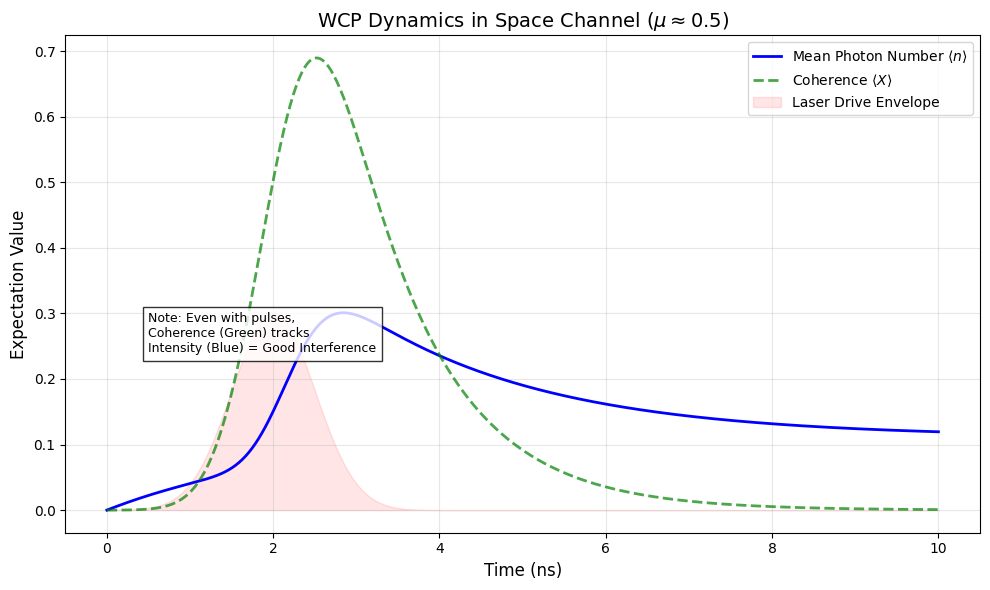

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from qutip import *

# ==========================================
# 1. PHYSICAL PARAMETERS & SPACE CONFIG
# ==========================================
# Basis size: N=5 is enough for weak pulses (mu < 1),
# but N=10 ensures mathematical accuracy for tails.
N = 10

# QKD Target Parameter: Mean Photon Number (mu)
# In Decoy-state BB84, signal states are usually mu ~ 0.5 to 0.6
target_mu = 0.5

# Environment (Space Channel)
temperature_kelvin = 20.0

# A. Transmission Loss (Amplitude Damping)
# This represents signal loss due to diffraction/atmosphere/coupling
# Unlike the QD lifetime, this is how fast photons leak out of the pulse mode.
decay_rate = 0.5  # GHz

# B. Phase Noise (Dephasing)
# This is CRITICAL for interference.
# Thermal gradients or atmospheric turbulence scramble the phase.
gamma_dephase_thermal = 0.05 * (temperature_kelvin / 4.0)**2
gamma_dephase_radiation = 0.2
gamma_total_dephase = gamma_dephase_thermal + gamma_dephase_radiation

# C. Background Noise (Thermal/Stray Light)
# Rate of thermal photons entering the mode
gamma_stray_light = 0.05

print(f"--- WCP QKD Source Parameters ---")
print(f"Target Mean Photon Number (mu): {target_mu}")
print(f"Channel Loss Rate: {decay_rate} GHz")
print(f"Phase Scrambling Rate: {gamma_total_dephase:.3f} GHz")
print("\n")

# ==========================================
# 2. PULSE DEFINITION
# ==========================================
# Pulse Parameters
period_ns = 10.0
pulse_width = 0.5  # slightly wider for better coherent definition
pulse_center = 2.0

# Calibrating the Drive Strength
# For a coherent state, the displacement alpha depends on integral of field.
# We approximate the amplitude required to reach mean photon number 'target_mu'.
# Area under Gaussian = Amp * width * sqrt(2*pi)
# We want final alpha = sqrt(target_mu)
# So Amp = sqrt(target_mu) / (width * sqrt(2*pi))
drive_amp = np.sqrt(target_mu) / (pulse_width * np.sqrt(2 * np.pi))

def laser_pulse_shape(t, args):
    return np.exp(-((t - args['center'])**2) / (2 * args['width']**2))

pulse_args = {'center': pulse_center, 'width': pulse_width}

# ==========================================
# 3. HAMILTONIAN & OPERATORS
# ==========================================
# Operators for Harmonic Oscillator (Bosonic Mode)
a = qt.destroy(N)       # Annihilation operator
n_op = a.dag() * a      # Number operator (counts photons)
x_op = a + a.dag()      # Position Quadrature (tracks Phase/Interference capability)

# Hamiltonian for a Driven Harmonic Oscillator
# H = i * hbar * E(t) * (a^dag - a)  <-- Displacement Hamiltonian
# This creates a Coherent State |alpha> from Vacuum |0>
H_drive = 1.0j * drive_amp * (a.dag() - a)

# Total H
H = [qt.qeye(N), [H_drive, laser_pulse_shape]]

# Collapse Operators (Lindblad Noise)
c_ops = []

# 1. Amplitude Damping (Loss)
# Corresponds to photon loss in the channel.
c_ops.append(np.sqrt(decay_rate) * a)

# 2. Phase Damping (Dephasing)
# Operator is n_op. This destroys off-diagonal terms (phase)
# without changing diagonal terms (population/energy).
c_ops.append(np.sqrt(gamma_total_dephase) * n_op)

# 3. Thermal/Stray Inflow
# Adds incoherent photons to the mode
c_ops.append(np.sqrt(gamma_stray_light) * a.dag())

# ==========================================
# 4. SOLVER
# ==========================================
tlist = np.linspace(0, 10, 500)
psi0 = qt.basis(N, 0) # Start in Vacuum State |0> (No photons)

# We track:
# 1. Expectation of n (Mean Photon Number)
# 2. Expectation of x (Phase Coherence - vital for interference)
result = mesolve(H, psi0, tlist, c_ops, [n_op, x_op], args=pulse_args)

exp_n = result.expect[0] # Intensity
exp_x = result.expect[1] # Coherence

# ==========================================
# 5. ANALYSIS & VISUALIZATION
# ==========================================
# In WCP QKD, we look at the Poisson Statistics.
# Probability of Multiphoton events (Security Risk): P(n>=2)
# For a coherent state P(n) = e^-mu * mu^n / n!
# We estimate actual mu from the peak of the pulse
peak_mu = np.max(exp_n)
prob_multi = 1 - (np.exp(-peak_mu) * (1 + peak_mu))

print(f"--- SIMULATION RESULTS ---")
print(f"Peak Mean Photon Number: {peak_mu:.4f}")
print(f"Est. Multiphoton Probability (Security Risk): {prob_multi:.4f}")

plt.figure(figsize=(10, 6))

# Plot 1: Intensity (Mean Photon Number)
plt.plot(tlist, exp_n, 'b-', linewidth=2, label=r'Mean Photon Number $\langle n \rangle$')

# Plot 2: Coherence (Quadrature)
# If this oscillates or follows the envelope, phase is preserved.
# If this is zero, you have light but no interference capability.
plt.plot(tlist, exp_x, 'g--', linewidth=2, alpha=0.7, label=r'Coherence $\langle X \rangle$')

# Laser Reference
laser_profile = [laser_pulse_shape(t, pulse_args)*peak_mu for t in tlist]
plt.fill_between(tlist, laser_profile, color='red', alpha=0.1, label='Laser Drive Envelope')

plt.title(f'WCP Dynamics in Space Channel ($\mu \\approx {target_mu}$)', fontsize=14)
plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('Expectation Value', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Annotations
plt.text(0.5, peak_mu*0.8, "Note: Even with pulses,\nCoherence (Green) tracks\nIntensity (Blue) = Good Interference", fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

--- WCP Source Configuration ---
Target Mean Photon Number (mu): 0.5
Model Truncation Level: 5 photons

--- Initial State Statistics (Satellite) ---
Prob(0 photons - Vacuum): 0.6065
Prob(1 photon  - Qubit):  0.3033
Prob(2+ photons - Error): 0.0900

--- Final State Statistics (Earth Receiver) ---
Prob(0 photons - Loss):   0.9753
Prob(1 photon  - Signal): 0.0242
Prob(2+ photons - Noise): 0.0003


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


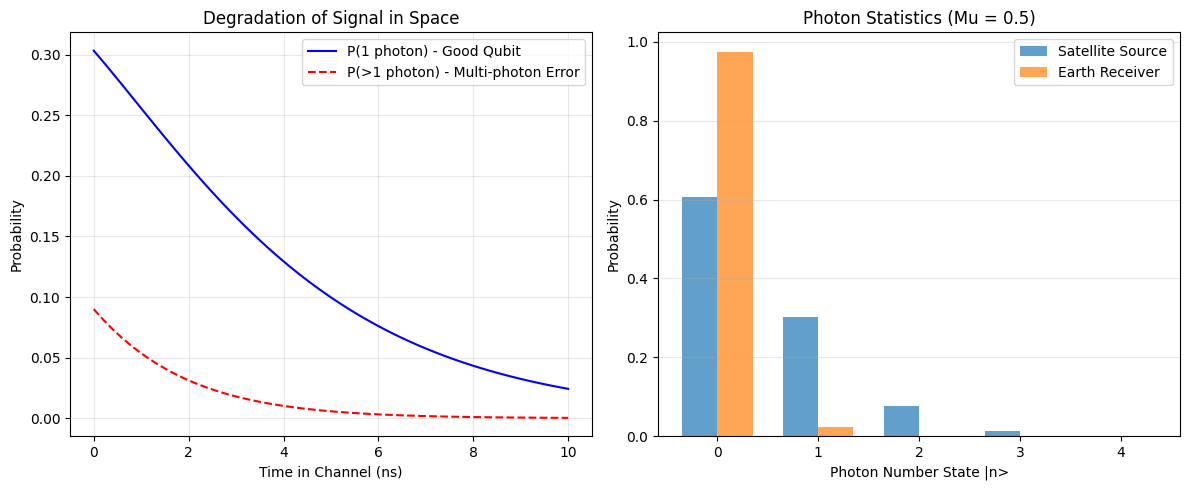

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import math
from qutip import *

# ==========================================
# 1. SETUP: The "Truncated" Basis
# ==========================================
# We use a Fock basis (particle counting basis).
# N=5 means we model 0, 1, 2, 3, 4 photons.
# We truncate at 5 because for weak pulses, P(5 photons) is roughly zero.
N = 5
psi_dictionary = {n: qt.basis(N, n) for n in range(N)}

# ==========================================
# 2. SOURCE PARAMETERS (The WCP)
# ==========================================
# Mean Photon Number (mu).
# For QKD, we usually keep this < 1.0 to avoid multiphoton security risks.
mu = 0.5

print(f"--- WCP Source Configuration ---")
print(f"Target Mean Photon Number (mu): {mu}")
print(f"Model Truncation Level: {N} photons")

# ==========================================
# 3. CONSTRUCTING THE PHASE-RANDOMIZED STATE
# ==========================================
# A perfect laser pulse has a fixed phase.
# A "Phase-Randomized" pulse is a mixture of all possible phases.
# Mathematically, this kills the off-diagonal "coherence" terms,
# leaving us with a diagonal density matrix of Poissonian statistics.

# Calculate probability of having n photons: P(n) = (e^-mu * mu^n) / n!
probs = []
density_matrix_parts = []

for n in range(N):
    # Poissonian Probability for n photons
    p_n = (np.exp(-mu) * (mu**n)) / math.factorial(n)
    probs.append(p_n)

    # Add this weighted component to the density matrix
    # rho = sum( P(n) * |n><n| )
    density_matrix_parts.append(p_n * psi_dictionary[n] * psi_dictionary[n].dag())

# This represents the state of your pulse LEAVING the satellite
rho_initial = sum(density_matrix_parts)

print("\n--- Initial State Statistics (Satellite) ---")
print(f"Prob(0 photons - Vacuum): {probs[0]:.4f}")
print(f"Prob(1 photon  - Qubit):  {probs[1]:.4f}")
print(f"Prob(2+ photons - Error): {sum(probs[2:]):.4f}")

# ==========================================
# 4. CHANNEL DYNAMICS (Space Loss)
# ==========================================
# Since we have phase-randomized the state, we are effectively
# sending classical probability packets. We can model the loss
# simply using the Lindblad Master Equation for amplitude damping.

# Time vector (nanoseconds)
tlist = np.linspace(0, 10, 100)

# Space Channel Parameters
decay_rate = 0.3  # Rate at which photons are lost to space
a = qt.destroy(N) # Annihilation operator

# The Hamiltonian is zero because we are in the interaction frame
# and just modeling decay, not active driving.
H = 0 * a.dag() * a

# Collapse operator: Photon Loss
c_ops = [np.sqrt(decay_rate) * a]

# Evolve the density matrix
result = mesolve(H, rho_initial, tlist, c_ops, [])

# ==========================================
# 5. ANALYSIS AT RECEIVER (Earth)
# ==========================================
# We want to see what the photon statistics look like after transmission.
# We extract the diagonal elements (populations) of the density matrix over time.

final_state = result.states[-1]
final_probs = [np.real(final_state.diag()[n]) for n in range(N)]

print("\n--- Final State Statistics (Earth Receiver) ---")
print(f"Prob(0 photons - Loss):   {final_probs[0]:.4f}")
print(f"Prob(1 photon  - Signal): {final_probs[1]:.4f}")
print(f"Prob(2+ photons - Noise): {sum(final_probs[2:]):.4f}")

# ==========================================
# 6. VISUALIZATION
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Transmission Dynamics
# Track the probability of having exactly 1 photon (The "Qubit") vs Time
p1_t = [np.real(state.diag()[1]) for state in result.states]
p_multi_t = [np.real(sum(state.diag()[2:])) for state in result.states]

ax[0].plot(tlist, p1_t, 'b-', label='P(1 photon) - Good Qubit')
ax[0].plot(tlist, p_multi_t, 'r--', label='P(>1 photon) - Multi-photon Error')
ax[0].set_xlabel('Time in Channel (ns)')
ax[0].set_ylabel('Probability')
ax[0].set_title('Degradation of Signal in Space')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Plot 2: Photon Number Distribution (Histogram)
# Comparing Source vs Receiver
width = 0.35
indices = np.arange(N)

ax[1].bar(indices - width/2, probs, width, label='Satellite Source', alpha=0.7)
ax[1].bar(indices + width/2, final_probs, width, label='Earth Receiver', alpha=0.7)
ax[1].set_xlabel('Photon Number State |n>')
ax[1].set_ylabel('Probability')
ax[1].set_title(f'Photon Statistics (Mu = {mu})')
ax[1].set_xticks(indices)
ax[1].legend()
ax[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()